In [2]:
# Install packages
!mamba install numpy
!mamba install pandas
!mamba install matplotlib
!mamba install scikit-learn

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.556 seconds
All requested packages already installed.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.1225 seconds
All requested packages already installed.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.26379999999702 seconds
All requested packages already installed.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.1250999999

In [3]:
# Load dataset
data = pd.read_csv("heart.csv")

# Display first 5 rows
print("First 5 Rows:")
print(data.head())

# Check dataset information
print("\nDataset Shape:")
print(data.shape)

print("\nMissing Values:")
print(data.isnull().sum())

# Features and Target
X = data.drop("target", axis=1)
y = data["target"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape:
(1025, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Features Shape: (1025, 13)
Target Shape: (1025,)


In [4]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


In [5]:
# Create Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9853658536585366


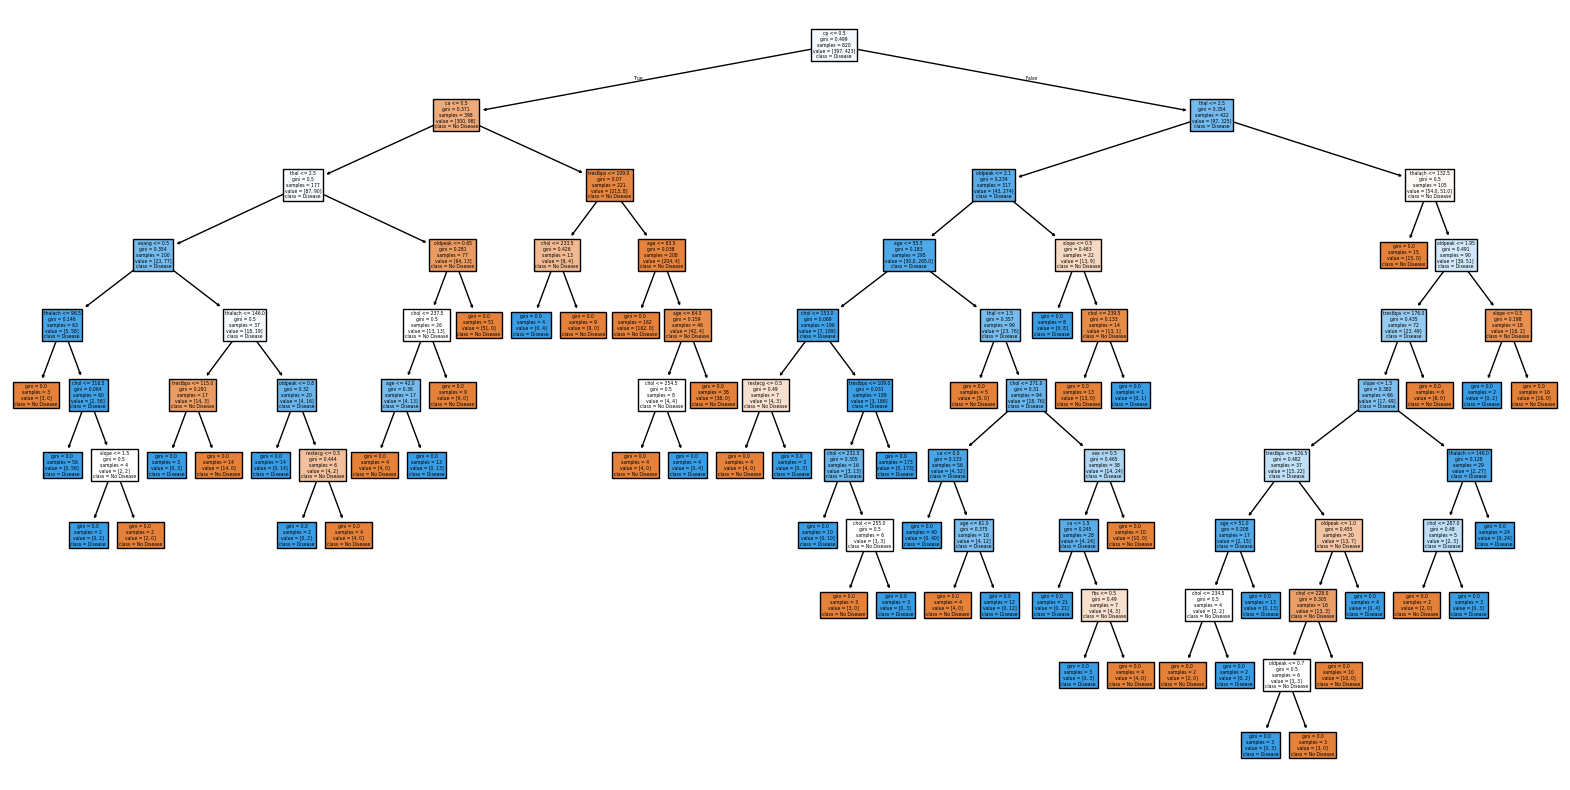

In [6]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"]
)

plt.show()

In [7]:
dt_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth3.fit(X_train, y_train)

y_pred_depth3 = dt_depth3.predict(X_test)

depth3_accuracy = accuracy_score(y_test, y_pred_depth3)

print("Decision Tree Accuracy (max_depth=3):", depth3_accuracy)

Decision Tree Accuracy (max_depth=3): 0.7804878048780488


In [8]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9853658536585366


In [9]:
print("\nModel Comparison")
print("------------------")
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)


Model Comparison
------------------
Decision Tree Accuracy : 0.9853658536585366
Random Forest Accuracy : 0.9853658536585366


In [10]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


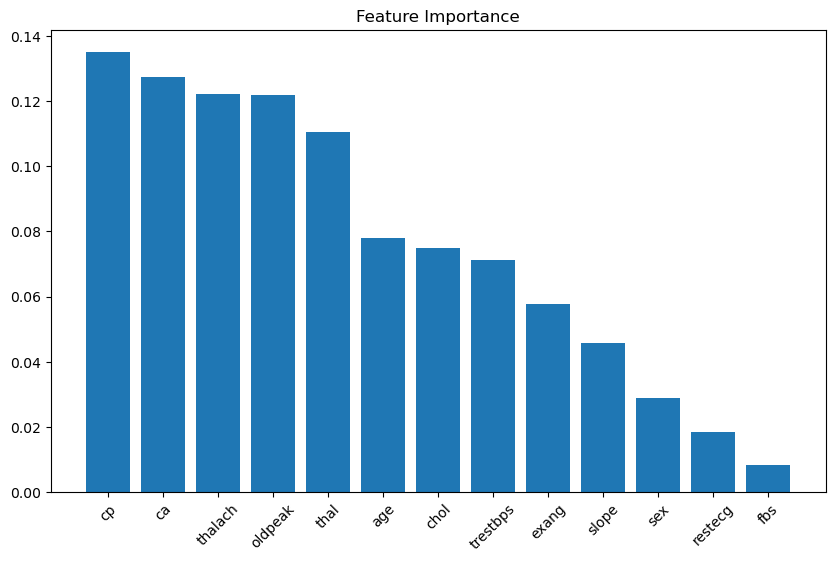

In [11]:
plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average CV Score:")
print(scores.mean())

Cross Validation Scores:
[1.         1.         1.         1.         0.98536585]
Average CV Score:
0.9970731707317073
